# Expectation Decider: Probability-Based Student Pass Prediction Analysis



In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [22]:
df = pd.read_csv("expectation_decider_dataset.csv")
df.head()

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,1,12.6,71,Yes,53,Fail
1,2,9.6,75,No,32,Fail
2,3,14.1,98,Yes,57,Fail
3,4,15.5,93,Yes,80,Pass
4,5,17.6,89,No,72,Pass


## Dataset Overview

The dataset contains 200 students and the following columns:

- student_id
- study_hours
- attendance
- group_discussion
- previous_test_score
- final_exam_pass

In [23]:
df.shape

(200, 6)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           200 non-null    int64  
 1   study_hours          200 non-null    float64
 2   attendance           200 non-null    int64  
 3   group_discussion     200 non-null    str    
 4   previous_test_score  200 non-null    int64  
 5   final_exam_pass      200 non-null    str    
dtypes: float64(1), int64(3), str(2)
memory usage: 9.5 KB


In [25]:
df.describe()

,student_id,study_hours,attendance,previous_test_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,10.680500,78.805000,66.515000
std,57.879185,4.612128,15.289073,19.733139
min,1.000000,3.000000,45.000000,25.000000
25%,50.750000,6.675000,68.000000,48.750000
50%,100.500000,11.700000,84.000000,71.000000
75%,150.250000,14.300000,91.000000,84.000000
max,200.000000,18.400000,98.000000,98.000000


## Probability Basics

Probability means the measure of chance that an event happening.

Formula:

P(Event) = Favourable Outcomes / Total Outcomes

In [26]:
total_students = len(df)

passed_students = (df["final_exam_pass"]=="Pass").sum()
failed_students = (df["final_exam_pass"]=="Fail").sum()

total_students, passed_students, failed_students

(200, np.int64(130), np.int64(70))

In [27]:
p_pass = passed_students / total_students
p_fail = failed_students / total_students

print("Probability of Pass:", p_pass)
print("Probability of Fail:", p_fail)

Probability of Pass: 0.65
Probability of Fail: 0.35


## Key Probability Terminology

- **Experiment:** An activity that produces an outcome.  
  Example: Selecting one student from the dataset.

- **Trial:** One performance of the experiment.  
  Example: Selecting one student once.

- **Outcome:** The result of a trial.  
  Example: The selected student passes or fails.

- **Sample Space:** All possible outcomes.  
  S = {Pass, Fail}

- **Event:** A specific outcome or group of outcomes we are interested in.  
  Example: A student passes the final exam.

## Probability Event Examples from the Dataset


In [28]:
# Total number of students
total_students = len(df)

# Event 1: Student passes
event_pass = (df["final_exam_pass"] == "Pass").sum()

# Event 2: Attendance greater than 80%
event_high_attendance = (df["attendance"] > 80).sum()

# Event 3: Participates in group discussion
event_group_discussion = (df["group_discussion"] == "Yes").sum()

# Probability calculations
p_pass = event_pass / total_students
p_high_attendance = event_high_attendance / total_students
p_group_discussion = event_group_discussion / total_students

print("Event 1 - Students who passed:", event_pass)
print("Probability of Pass:", round(p_pass,2))

print("\nEvent 2 - Students with attendance > 80%:", event_high_attendance)
print("Probability of High Attendance:", round(p_high_attendance,2))

print("\nEvent 3 - Students who participated in group discussion:", event_group_discussion)
print("Probability of Group Discussion:", round(p_group_discussion,2))

Event 1 - Students who passed: 130
Probability of Pass: 0.65

Event 2 - Students with attendance > 80%: 118
Probability of High Attendance: 0.59

Event 3 - Students who participated in group discussion: 110
Probability of Group Discussion: 0.55


## Types of Probability

Empirical probability is calculated from actual data.

Theoretical probability is calculated using logical assumption or formula.

In [29]:
empirical_pass_probability = passed_students / total_students
theoretical_pass_probability = 1 / 2

print("Empirical Probability of Pass:", empirical_pass_probability)
print("Theoretical Probability of Pass:", theoretical_pass_probability)

Empirical Probability of Pass: 0.65
Theoretical Probability of Pass: 0.5


## Random Variable and Probability Distribution

Let X = Number of students passing out of 3 randomly selected students.

Possible values of X are:

- X = 0: No student passes
- X = 1: One student passes
- X = 2: Two students passes
- X = 3: Three students passes

In [30]:
p = p_pass
q = p_fail

prob_x0 = q * q * q
prob_x1 = 3 * p * q * q
prob_x2 = 3 * p * p * q
prob_x3 = p * p * p

distribution = pd.DataFrame({
    "X": [0, 1, 2, 3],
    "Meaning": [
        "No student passes",
        "One student passes",
        "Two students pass",
        "Three students pass"
    ],
    "Probability": [prob_x0, prob_x1, prob_x2, prob_x3]
})

distribution

,X,Meaning,Probability
0,0,No student passes,0.042875
1,1,One student passes,0.238875
2,2,Two students pass,0.443625
3,3,Three students pass,0.274625


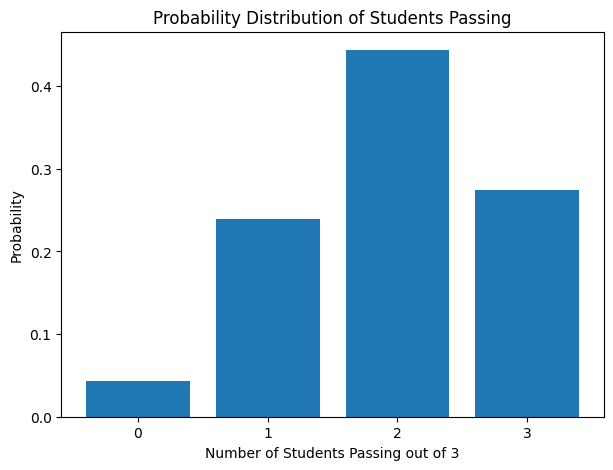

In [31]:
plt.figure(figsize=(7, 5))
plt.bar(distribution["X"], distribution["Probability"])

plt.xlabel("Number of Students Passing out of 3")
plt.ylabel("Probability")
plt.title("Probability Distribution of Students Passing")
plt.xticks([0, 1, 2, 3])
plt.show()

In [32]:
mean_x = sum(distribution["X"] * distribution["Probability"])
variance_x = sum(((distribution["X"] - mean_x) ** 2) * distribution["Probability"])

print("Mean:", (round(mean_x,2)))
print("Variance:", variance_x)

Mean: 1.95
Variance: 0.6825


## Venn Diagram in Probability

A = Students who study more than 10 hours per week  
B = Students who attend more than 80% of classes

The overlap shows students who satisfy both conditions.

Study hours > 10 only: 25
Attendance > 80 only: 38
Both conditions: 80
Neither: 57


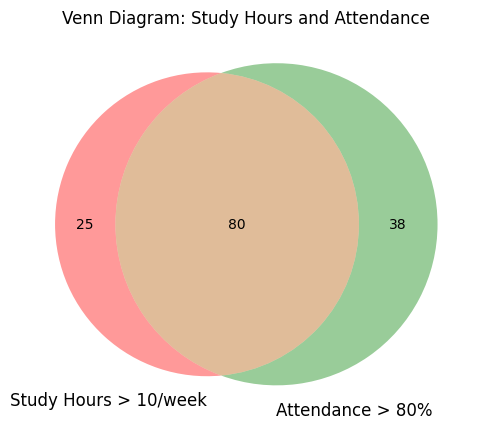

In [33]:
A = df["study_hours"] > 10
B = df["attendance"] > 80

a_only = (A & ~B).sum()
b_only = (~A & B).sum()
both = (A & B).sum()
neither = (~A & ~B).sum()

print("Study hours > 10 only:", a_only)
print("Attendance > 80 only:", b_only)
print("Both conditions:", both)
print("Neither:", neither)

plt.figure(figsize=(10, 5))
venn2(subsets=(a_only, b_only, both),set_labels=("Study Hours > 10/week", "Attendance > 80%"))
plt.title("Venn Diagram: Study Hours and Attendance")
plt.show()

## Contingency Table

A contingency table shows the relationship between two categorical variables.

Here, we analyze:

- group_discussion
- final_exam_pass

In [34]:
contingency_table = pd.crosstab(df["group_discussion"],df["final_exam_pass"],margins=True)

contingency_table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,50,40,90
Yes,20,90,110
All,70,130,200


## Joint probability of Participates in group discussion AND Passes exam

P (Group Discussion = Yes intersect Pass) = ??

In [35]:
joint_yes_pass = 90 / 200

print("Joint Probability of Group Discussion Yes and Pass:", joint_yes_pass)

Joint Probability of Group Discussion Yes and Pass: 0.45


## Marginal probability of Passes exam

P(Pass) = ??

In [36]:
marginal_pass = 130 / 200

print("Marginal Probability of Pass:", marginal_pass)

Marginal Probability of Pass: 0.65


## Conditional probability of Passes exam given participation in group discussion  

P(Pass | Group Discussion = Yes) = ??

In [37]:
conditional_pass_given_group_yes = 90 / 110

print("P(Pass | Group Discussion = Yes):", round(conditional_pass_given_group_yes,2))

P(Pass | Group Discussion = Yes): 0.82


## Understanding Relationships

Overall probability of passing:

P(Pass) = 130 / 200 = 65%

Probability of passing given group discussion:

P(Pass | Group Discussion = Yes) = 90 / 110 = 81.82%

Since 81.82% is greater than 65%, students who participate in group discussion have a higher chance of passing.

So, group discussion and passing are dependent events.

## Bayes Theorem Application

Given:

- P(High Attendance | Pass) = 0.70
- P(High Attendance | Fail) = 0.40
- P(High Attendance) = 0.60
- P(Pass) = 0.65

Formula:

P(Pass | High Attendance) = P(High Attendance | Pass) × P(Pass) / P(High Attendance)

In [38]:
p_high_attendance_given_pass = 0.70
p_high_attendance = 0.60
p_pass = 0.65

p_pass_given_high_attendance = (p_high_attendance_given_pass * p_pass) / p_high_attendance

print("P(Pass | High Attendance):", round(p_pass_given_high_attendance,2))
print("Percentage:", round(p_pass_given_high_attendance * 100,2))

P(Pass | High Attendance): 0.76
Percentage: 75.83


## Final Summary

From this project, i analyzed the probability of students passing the final exam using study hours, attendance, group discussion, and previous test score.

The overall probability of passing is 65%.

Students who participated in group discussion had a higher passing probability of 81.82%.

The Venn diagram showed that 80 students had both good study hours and high attendance.

Using Bayes Theorem, the probability of passing given high attendance is 75.83%.

Therefore, the most important factors affecting passing probability are:

1. Group discussion
2. High attendance
3. More study hours
4. Previous test performance